<div style="text-align: justify; max-width: 90ch">

# Lecture 02c: Chunking: size, overlap and metadata

**Status: Mandatory reading.**

`lec_02b` cut the notes at their headings and met two problems: some sections were too long for the embedding model and had to be cut at 4,000 characters,
losing the rest, and an almost empty heading won a search. How you cut documents into pieces, **chunking**, decides what retrieval can find.

**What this notebook covers**

- The embedding model's own tokens: why `GridSearchCV` got lost, and how long the sections really are.
- Why chunk: the context window, and one blurry vector per long section.
- A recursive splitter that cuts at headings first, then paragraphs, lines and words.
- **Overlap**, and the seam it repairs.
- **Metadata**: every chunk remembers where it came from.
- Choosing a chunk size.

</div>

In [1]:
import os
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import ollama
import pandas as pd
from dotenv import load_dotenv
from langchain_text_splitters import RecursiveCharacterTextSplitter
from transformers import AutoTokenizer

from llm_course.corpus import load_corpus, load_sections

In [2]:
# --- Course configuration: edit TIER only; settings in .env (Read: 01d_env_hugging_face) ---
TIER = "cpu"  # 8-16 GB RAM, no GPU (default)
# TIER = "gpu"  # >= 8 GB VRAM: bigger, better answers (pull qwen3:8b first)

REPO = Path.cwd().resolve().parents[1]  # this notebook runs from reading_material/
load_dotenv(REPO / ".env")  # load your .env settings: OLLAMA_HOST, HF_TOKEN, ...
TIER = os.environ.get("COURSE_TIER", TIER)  # tools/run_all.py can override
os.environ.setdefault(
    "HF_HUB_DISABLE_PROGRESS_BARS", "1"
)  # no download bars in saved outputs
CHAT_MODEL = {"cpu": "qwen3:1.7b", "gpu": "qwen3:8b"}[TIER]
EMBED_MODEL = "nomic-embed-text"
OLLAMA_HOST = os.environ.get("OLLAMA_HOST", "http://localhost:11434")
MLFLOW_URI = os.environ.get("MLFLOW_TRACKING_URI", "http://127.0.0.1:5010")
# To override .env in this notebook only, uncomment and edit (never a token):
# OLLAMA_HOST = "http://192.168.1.20:11434"
# MLFLOW_URI = "http://127.0.0.1:5011"
EXPERIMENT = "llm-course-02-rag"
DATA_DIR = REPO / "data"  # gitignored runtime state (indexes, caches)

from llm_course.checks import check_ollama

check_ollama(OLLAMA_HOST, [CHAT_MODEL])

Ollama OK at http://localhost:11434; models ready: qwen3:1.7b


<div style="text-align: justify; max-width: 90ch">

**Rebuild inputs.** The sections of `lec_02b`, in one line: `load_sections` is the splitter written there, promoted to `llm_course`.

</div>

In [3]:
sections = load_sections(REPO / "corpus" / "uoa_py_course", lectures=[10, 11, 12, 13])
print(len(sections), "sections")

414 sections


<div style="text-align: justify; max-width: 90ch">

## 1. The embedding model's tokens

Every model reads **tokens** (`lec_01a`), and every model family has its own tokenizer. `nomic-embed-text` uses the tokenizer published with it on the Hugging Face Hub ([model card](https://huggingface.co/nomic-ai/nomic-embed-text-v1.5));
`transformers` downloads it in a second, as it did for Qwen in `lec_01a`. The card advertises 8192 tokens, but Ollama's build reports a context length of 2048 (`ollama show nomic-embed-text`),
and that is the limit that applies here.

</div>

In [4]:
tokenizer = AutoTokenizer.from_pretrained("nomic-ai/nomic-embed-text-v1.5")

tokenizer.tokenize("What does GridSearchCV do?")

['what', 'does', 'grid', '##sea', '##rch', '##c', '##v', 'do', '?']

<div style="text-align: justify; max-width: 90ch">

`GridSearchCV` becomes five fragments that mean nothing on their own (`##` marks a piece that continues the previous one).
The embedding model never saw the class name as one word, which is part of why `lec_02b`'s question matched generic sections.
Now the length of every section, in these tokens:

</div>

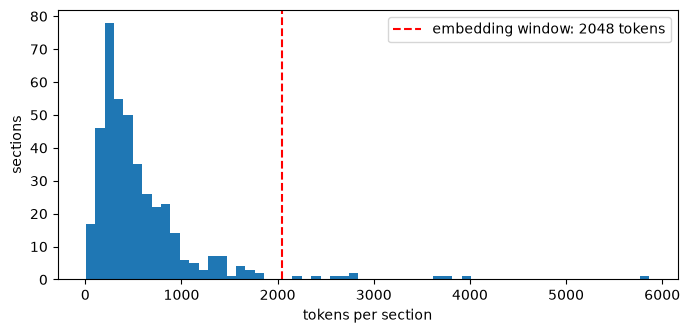

median 414 tokens, longest 5867
10 sections over the window, 1 under 20 tokens


In [5]:
section_tokens = np.array([len(tokenizer(s["text"])["input_ids"]) for s in sections])

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.hist(section_tokens, bins=60)
ax.axvline(2048, color="red", linestyle="--", label="embedding window: 2048 tokens")
ax.set_xlabel("tokens per section")
ax.set_ylabel("sections")
ax.legend()
plt.show()

print(f"median {np.median(section_tokens):.0f} tokens, longest {section_tokens.max()}")
print(
    f"{(section_tokens > 2048).sum()} sections over the window, {(section_tokens < 20).sum()} under 20 tokens"
)

<div style="text-align: justify; max-width: 90ch">

Most sections hold a few hundred tokens, but the tail is long: the sections over the red line cannot be embedded whole at all,
which is why `lec_02b` played safe and cut every section at 4,000 characters, losing the rest. At the other end sits the `## Setup` heading that won the `GridSearchCV` search:
a text that short gets a generic vector, close to every short question. Section 5 deals with it.

</div>

<div style="text-align: justify; max-width: 90ch">

## 2. Why chunk

Try to embed the longest section as it is:

</div>

In [6]:
# WRONG: embed a whole section, however long
check_ollama(OLLAMA_HOST, [EMBED_MODEL])
client = ollama.Client(host=OLLAMA_HOST)
longest = max(sections, key=lambda s: len(s["text"]))
print(
    longest["source"], "|", longest["heading"], "|", len(longest["text"]), "characters"
)

try:
    client.embed(model=EMBED_MODEL, input=longest["text"])
except ollama.ResponseError as error:
    print("ResponseError:", error)

Ollama OK at http://localhost:11434; models ready: nomic-embed-text
lecture_10/lec_10a_knn_classification.md | ## B1.3 — A new concept: the train / test split | 20155 characters
ResponseError: the input length exceeds the context length (status code: 400)


<div style="text-align: justify; max-width: 90ch">

The call fails: the text does not fit the model's window. And even a section that fits becomes **one** vector, an average of everything it discusses,
so a question about one paragraph matches it only weakly. **Chunking** cuts documents into pieces small enough to embed and focused enough to match one question.
It has two knobs: **size** and **overlap**.

</div>

<div style="text-align: justify; max-width: 90ch">

## 3. A recursive splitter

The simplest cut is every 800 characters:

</div>

In [7]:
# WRONG: fixed-width slices ignore words, sentences and headings
text = longest["text"]
slices = [text[i : i + 800] for i in range(0, len(text), 800)]
for piece in slices[1:3]:
    print(repr(piece[:70]))

'ing step and use it only for evaluation. That is the **train/test spli'
' Smaller test sets give a noisier accuracy estimate; bigger ones leave'


<div style="text-align: justify; max-width: 90ch">

Slices start in the middle of a word. LangChain's `RecursiveCharacterTextSplitter` tries a list of **separators** in order:
it cuts at the first one that yields pieces no longer than `chunk_size` characters, and only falls back to the next when a piece is still too long.
Our list tries headings first, then paragraphs, lines and words.

</div>

In [8]:
# RIGHT: cut at headings, then paragraphs, then lines, then words
HEADINGS_FIRST = ["\n## ", "\n### ", "\n\n", "\n", " ", ""]
splitter = RecursiveCharacterTextSplitter(
    separators=HEADINGS_FIRST, chunk_size=800, chunk_overlap=0
)

pieces = splitter.split_text(text)
print(len(pieces), "chunks")
for piece in pieces[:4]:
    print(len(piece), repr(piece[:60]))

vectors = client.embed(model=EMBED_MODEL, input=pieces).embeddings
print(len(vectors), "vectors: every chunk fits the window")

34 chunks
390 '## B1.3 — A new concept: the train / test split\n\nUp to this '
548 'Supervised learning is different. From this lecture forward,'
573 '### What the split actually does\n\n`train_test_split(X, y, te'
636 '- `test_size` — what fraction goes to the test set. Common c'


34 vectors: every chunk fits the window


<div style="text-align: justify; max-width: 90ch">

Every chunk now starts at a heading or a paragraph, and every chunk fits the embedding window. `chunk_size` counts characters, not tokens:
on these notes, full of code and symbols, one token is about three characters, so a full 800-character chunk holds about 250 tokens;
most chunks are shorter than the limit.

### ⏸ Pause point

LangChain also ships a ready-made separator list for Markdown, which cuts before any line starting with `#`. In one example run on these notes,
it cut code blocks in the middle about twice as often as the list above (446 cuts against 223). Why? Look at what a line starting with `# ` means *inside* a Python code block.

</div>

<div style="text-align: justify; max-width: 90ch">

## 4. Overlap

When a paragraph is longer than `chunk_size`, the cut falls inside it, and an idea can be split across two chunks with neither holding it whole.
**Overlap** repeats the end of each chunk at the start of the next. A small example, with tiny chunks so the seam is visible:

</div>

In [9]:
paragraph = (
    "Data leakage means that information from the test set reaches the model during training. "
    "The most common cause is fitting a scaler on the whole dataset before the split. "
    "The scaler then learns the mean and standard deviation of the test rows as well, "
    "so the test score looks better than the model deserves."
)

for overlap in [0, 40]:
    small = RecursiveCharacterTextSplitter(
        separators=HEADINGS_FIRST, chunk_size=130, chunk_overlap=overlap
    )
    print(f"chunk_overlap={overlap}")
    for piece in small.split_text(paragraph):
        print("   ", repr(piece))

chunk_overlap=0
    'Data leakage means that information from the test set reaches the model during training. The most common cause is fitting a scaler'
    'on the whole dataset before the split. The scaler then learns the mean and standard deviation of the test rows as well, so the'
    'test score looks better than the model deserves.'
chunk_overlap=40
    'Data leakage means that information from the test set reaches the model during training. The most common cause is fitting a scaler'
    'most common cause is fitting a scaler on the whole dataset before the split. The scaler then learns the mean and standard'
    'then learns the mean and standard deviation of the test rows as well, so the test score looks better than the model deserves.'


<div style="text-align: justify; max-width: 90ch">

Without overlap, "fitting a scaler | on the whole dataset" is torn apart and no chunk says what the cause of leakage is.
With 40 characters of overlap the second chunk holds the whole cause. The price: more chunks, and the same words embedded twice.
Overlaps of 10 to 20 percent of the chunk size are common; the course uses an eighth, 100 of 800 characters.

</div>

<div style="text-align: justify; max-width: 90ch">

## 5. Metadata: every chunk remembers its source

A chunk on its own is anonymous text. To cite a source (`lec_02b`) or to search only the lecture notes (`lec_02d`), each chunk carries **metadata**.
LangChain's **`Document`** is that pair: `page_content` (the text) and `metadata` (a dict). `load_corpus` returns one `Document` per file, and the splitter copies each file's metadata into every chunk it cuts.
`load_corpus` also removes the export note on each file's first line (`<!-- source: ... -->`): the file path belongs in the metadata, where its words cannot match questions about "lectures" or "data".

</div>

In [10]:
documents = load_corpus(REPO / "corpus" / "uoa_py_course", lectures=[10, 11, 12, 13])
splitter = RecursiveCharacterTextSplitter(
    separators=HEADINGS_FIRST, chunk_size=800, chunk_overlap=100, add_start_index=True
)
chunks = splitter.split_documents(documents)

print(len(documents), "documents ->", len(chunks), "chunks")
chunks[300]

41 documents -> 1454 chunks


Document(metadata={'source': 'lecture_11/goals_11.md', 'lecture': 11, 'kind': 'goals', 'title': 'Lecture 11: Linear Regression — APIs, Assumptions, Multiple, Pitfalls, Polynomial', 'start_index': 2434}, page_content='### AI Fluency\n\n- **A1.** Recognise the regression-specific failure modes of AI coding assistants (hallucinated `random_state` parameters, inference/prediction conflation, multicollinearity blind spots, scaling-before-split leakage). Use the 4Ds framework (Delegation / Description / Discernment / Diligence) to verify assistant-generated regression code. *(file: `read_agents_regression_workflows.md`)*')

<div style="text-align: justify; max-width: 90ch">

`kind` separates lecture notes from exercises, solutions and readings, which matters in `lec_02d`; `start_index` says where in the file the chunk begins.

One more cleanup. When the text under a heading is too long to join it, the splitter leaves the heading alone in a chunk.
Such a chunk answers nothing, and like the `## Setup` section of `lec_02b`, its generic vector sits close to every short question:

</div>

In [11]:
# RIGHT: drop pieces too short to answer anything
tiny = [c for c in chunks if len(c.page_content) < 80]
print(
    len(tiny),
    "chunks under 80 characters, for example:",
    [c.page_content.strip() for c in tiny[:5]],
)

chunks = [c for c in chunks if len(c.page_content) >= 80]
print(len(chunks), "chunks kept")

83 chunks under 80 characters, for example: ['# Lecture 10: KNN classifier + train/test split', '## Learning Goals', '### Required', '## Files', '### Required']
1371 chunks kept


<div style="text-align: justify; max-width: 90ch">

The promoted `llm_course.rag.split_documents` does all of this: headings-first separators, pieces under 80 characters dropped,
and the nearest heading above each chunk recorded in its metadata.

</div>

<div style="text-align: justify; max-width: 90ch">

## 6. Choosing a chunk size

Smaller chunks match a question more precisely but need more vectors, more embedding time and more storage; larger chunks are fewer but blurrier, and every retrieved chunk takes room in the chat model's prompt.
Three sizes, on the lecture 13 notes:

⏱ **Skip if running long.** Embedding three versions of lecture 13 takes a minute or two on a CPU; nothing below depends on it.

</div>

In [12]:
lecture_13 = load_corpus(REPO / "corpus" / "uoa_py_course", lectures=[13])
rows = []
for size in [300, 800, 2000]:
    sized = RecursiveCharacterTextSplitter(
        separators=HEADINGS_FIRST, chunk_size=size, chunk_overlap=size // 8
    ).split_documents(lecture_13)
    texts = [c.page_content for c in sized]
    started = time.time()
    for start in range(0, len(texts), 64):
        client.embed(model=EMBED_MODEL, input=texts[start : start + 64])
    rows.append(
        {
            "chunk_size": size,
            "chunks": len(texts),
            "median tokens": int(
                np.median([len(tokenizer(t)["input_ids"]) for t in texts])
            ),
            "embedding seconds": round(time.time() - started, 1),
        }
    )
pd.DataFrame(rows)

,chunk_size,chunks,median tokens,embedding seconds
0,300,928,65,3.9
1,800,337,182,2.1
2,2000,132,442,2.1


<div style="text-align: justify; max-width: 90ch">

The course uses **800 characters with an overlap of 100**: a median of about 180 tokens per chunk in the table, so four retrieved chunks add about 1,000 tokens to a prompt.
Whether that retrieves the right notes is a question for measurement, not taste: `lec_02d` builds an evaluation set and measures it, and the exercises sweep the size.

</div>

<div style="text-align: justify; max-width: 90ch">

## Recap

- The embedding model has its own tokenizer and a 2048-token window; long sections fail, code names shatter.
- **Chunking** makes pieces small enough to embed and focused enough to match one question.
- `RecursiveCharacterTextSplitter` tries separators in order: headings, paragraphs, lines, words. Check a preset against your documents before trusting it.
- **Overlap** repeats the edge of each chunk so an idea cut at a boundary survives whole in one of them.
- Drop pieces too short to answer anything: a heading alone matches every short question.
- A **`Document`** is text plus metadata; chunks inherit their file's metadata, which makes citations and filters possible.

**Next: `lec_02d`**, which stores the chunks of all thirteen lectures in a vector database, builds the LangChain RAG chain,
and measures retrieval. Its one-time ingestion takes a few minutes on a CPU: start its first cells before you read it.

</div>